## LBT (Learning Block Transformation) image compression

### Autores
- Daniel Salas Alonso
- José Carlos Ruíz Sánchez
- Millán Millán Posadas
- Anass El Jabiry Kaddir

### Explicación teórica de LBT

**LBT (Learning Block Transform)** es una transformada espacial aprendida que reemplaza las bases fijas de la DCT por matrices de transformación entrenadas con redes neuronales. La idea principal es que, en lugar de usar funciones coseno predefinidas, el sistema aprende las bases óptimas para una imagen específica.

#### Arquitectura del modelo (`LBTModel`)

El modelo consiste en dos capas lineales sin bias:
- **Encoder**: Transforma los bloques de píxeles en coeficientes (similar a la DCT directa)
- **Decoder**: Reconstruye los píxeles desde los coeficientes (similar a la DCT inversa)

Ambas capas se inicializan como matrices identidad, de modo que sin entrenamiento el sistema actúa como un "pass-through".

#### Flujo de codificación

1. La imagen se divide en bloques de $B \times B$ píxeles
2. Cada bloque se aplana a un vector de $B^2$ elementos
3. Se entrena el modelo minimizando el error de reconstrucción (MSE) y maximizando la energía por bloque.
4. Los pesos entrenados se guardan como **side information** (archivo `.weights.pth`)
5. Los coeficientes transformados se cuantizan y codifican

#### Uso en VCF

LBT es una capa de **transformada espacial** dentro de la jerarquía de codecs de VCF. Se sitúa al mismo nivel que `2D-DCT` y `2D-DWT`. Los argumentos principales son:

| Argumento | Descripción |
|-----------|-------------|
| `-B, --block_size` | Tamaño de bloque (por defecto: 8) |
| `--epochs` | Número de épocas de entrenamiento (por defecto: 1000) |
| `--lr` | Tasa de aprendizaje (por defecto: 1e-3) |
| `-L, --Lambda` | Peso del término de coding gain en la función de pérdida |
| `-q` | Indica el nivel de cuantización |
| `-p` | Activa cuantización perceptual |

## Implementación

In [121]:
%%writefile ../src/LBT.py
'''Exploiting spatial redundancy with the 2D Discrete Cosine Transform of constant block size.'''

import io
#from skimage import io as skimage_io # pip install scikit-image
import numpy as np
#import pywt # pip install pywavelets
import os
import torch
import torch.nn as nn
import torch.optim as optim
import logging
import main
with open("/tmp/description.txt", 'w') as f:
    f.write(__doc__)
import parser
import importlib
import struct

#from DWT import color_dyadic_DWT as DWT
from DCT2D.block_DCT import get_subbands
from DCT2D.block_DCT import get_blocks


from color_transforms.YCoCg import from_RGB # pip install "color_transforms @ git+https://github.com/vicente-gonzalez-ruiz/color_transforms"
from color_transforms.YCoCg import to_RGB

from information_theory import distortion # pip install "information_theory @ git+https://github.com/vicente-gonzalez-ruiz/information_theory"

import cv2

default_block_size = 8
default_CT = "YCoCg"
perceptual_quantization = False
disable_subbands = False

#_parser, parser_encode, parser_decode = parser.create_parser(description=__doc__)

parser.parser_encode.add_argument("-B", "--block_size_DCT", type=parser.int_or_str, help=f"Block size (default: {default_block_size})", default=default_block_size)
parser.parser_encode.add_argument("--side_info", type=str, help="Ruta para guardar los pesos entrenados (opcional)", default=None)
parser.parser_encode.add_argument("--epochs", type=int, help="Number of training epochs", default=1000)
parser.parser_encode.add_argument("--lr", type=float, help="Learning rate", default=1e-3)
parser.parser_encode.add_argument("-t", "--color_transform", type=parser.int_or_str, help=f"Color transform (default: \"{default_CT}\")", default=default_CT)
parser.parser_encode.add_argument("-p", "--perceptual_quantization", action='store_true', help=f"Use perceptual quantization (default: \"{perceptual_quantization}\")", default=perceptual_quantization)
parser.parser_encode.add_argument("-L", "--Lambda", type=parser.int_or_str, help="Relative weight between the rate and the distortion. If provided (float), the block size is RD-optimized between {2**i; i=1,2,3,4,5,6,7}. For example, if Lambda=1.0, then the rate and the distortion have the same weight.")
parser.parser_encode.add_argument("-x", "--disable_subbands", action='store_true', help=f"Disable the coefficients reordering in subbands (default: \"{disable_subbands}\")", default=disable_subbands)




parser.parser_decode.add_argument("-B", "--block_size_DCT", type=parser.int_or_str, help=f"Block size (default: {default_block_size})", default=default_block_size)
parser.parser_decode.add_argument("--side_info", type=str, help="Ruta para cargar los pesos entrenados (opcional)", default=None)
parser.parser_decode.add_argument("-t", "--color_transform", type=parser.int_or_str, help=f"Color transform (default: \"{default_CT}\")", default=default_CT)
parser.parser_decode.add_argument("-p", "--perceptual_quantization", action='store_true', help=f"Use perceptual dequantization (default: \"{perceptual_quantization}\")", default=perceptual_quantization)
parser.parser_decode.add_argument("-x", "--disable_subbands", action='store_true', help=f"Disable the coefficients reordering in subbands (default: \"{disable_subbands}\")", default=disable_subbands)

args = parser.parser.parse_known_args()[0]
CT = importlib.import_module(args.color_transform)

class LBTModel(nn.Module):
    def __init__(self, n_features):
        super(LBTModel, self).__init__()
        # Encoder: Input -> Coeficientes
        self.encoder = nn.Linear(n_features, n_features, bias=False)
        # Decoder: Coeficientes -> Reconstrucción
        self.decoder = nn.Linear(n_features, n_features, bias=False)

        # Inicialización Identidad
        self.reset_weights()

    def reset_weights(self):
        nn.init.normal_(self.encoder.weight, std=0.02)
        nn.init.normal_(self.decoder.weight, std=0.02)

    def forward(self, x):
        y = self.encoder(x)
        x_hat = self.decoder(y)
        return x_hat, y

class LearnedBlockTransform:
    def __init__(self, block_size: int, epochs: int = 100, lr: float = 1e-3, lambda_gain: float = 1e-6):
        self.B = block_size
        self.N = block_size * block_size
        self.model = LBTModel(self.N)
        self.mean_val = 0.0

        self.epochs = epochs
        self.lr = lr
        self.lambda_gain = lambda_gain

    def encode_image(self, img, side_info_file):
        """
        1. Entrena el modelo con 'img'.
        2. Guarda los pesos en 'side_info_file'.
        3. Retorna la imagen transformada.
        """
        # --- Paso 1: Preparar datos ---
        self.model.reset_weights() # Reiniciar pesos para entrenar desde cero
        self.model.train()
        
        blocks_flat = self._extract_blocks(img).reshape(-1, self.N)
        X = torch.from_numpy(blocks_flat).float()
        
        # Calcular media actual para centrar
        self.mean_val = X.mean().item()
        X = X - self.mean_val

        # --- Paso 2: Entrenamiento (Interno) ---
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        for _ in range(self.epochs):
            optimizer.zero_grad()
            x_hat, y = self.model(X)
            
            # Loss: MSE + Coding Gain
            mse_loss = torch.mean((x_hat - X)**2)

            if self.lambda_gain > 0:
                variances = torch.var(y, dim=0, unbiased=False) + 1e-6
                coding_gain_loss = torch.mean(torch.log(variances))
                loss = mse_loss + self.lambda_gain * coding_gain_loss
            else:
                loss = mse_loss

            loss.backward()
            optimizer.step()

        # --- Paso 3: Guardar Side Info ---
        # Guardamos pesos y la media necesaria para decodificar
        torch.save({
            'state_dict': self.model.state_dict(),
            'mean_val': self.mean_val
        }, side_info_file)

        # --- Paso 4: Codificación (Inferencia) ---
        self.model.eval()
        with torch.no_grad():
            y_coeffs = self.model.encoder(X)
            y_numpy = y_coeffs.numpy()

        H, W, C = img.shape
        return self._reconstruct_map(y_numpy, (H, W, C))

    def decode_image(self, coeffs_img, shape, side_info_file):
        """
        1. Carga pesos desde 'side_info_file'.
        2. Retorna imagen reconstruida.
        """
        # --- Paso 1: Cargar Modelo ---
        if not os.path.exists(side_info_file):
            raise FileNotFoundError(f"No se encuentra el archivo de pesos: {side_info_file}")
            
        checkpoint = torch.load(side_info_file)
        self.model.load_state_dict(checkpoint['state_dict'])
        self.mean_val = checkpoint['mean_val']
        
        self.model.eval()

        # --- Paso 2: Decodificación ---
        H, W, C = shape
        coeffs_flat = self._extract_blocks(coeffs_img).reshape(-1, self.N)
        
        with torch.no_grad():
            Y = torch.from_numpy(coeffs_flat).float()
            x_recon = self.model.decoder(Y)
            # Sumar la media guardada
            x_recon = x_recon + self.mean_val
            x_numpy = x_recon.numpy()

        return self._reconstruct_map(x_numpy, (H, W, C))

    def _extract_blocks(self, img):
        if img.ndim == 2: img = img[:, :, np.newaxis]
        H, W, C = img.shape
        blocks = []
        for ch in range(C):
            for y in range(0, H, self.B):
                for x in range(0, W, self.B):
                    block = img[y:y+self.B, x:x+self.B, ch]
                    if block.shape[0] < self.B or block.shape[1] < self.B:
                        padded = np.zeros((self.B, self.B))
                        padded[:block.shape[0], :block.shape[1]] = block
                        blocks.append(padded)
                    else:
                        blocks.append(block)
        return np.array(blocks)

    def _reconstruct_map(self, flat_blocks, shape):
        H, W, C = shape
        out = np.zeros(shape, dtype=np.float32)
        idx = 0
        for ch in range(C):
            for y in range(0, H, self.B):
                for x in range(0, W, self.B):
                    ph, pw = min(self.B, H - y), min(self.B, W - x)
                    block_flat = flat_blocks[idx]
                    out[y:y+ph, x:x+pw, ch] = block_flat.reshape(self.B, self.B)[:ph, :pw]
                    idx += 1
        return out

class CoDec(CT.CoDec):

    def __init__(self, args):
        logging.debug("trace")
        super().__init__(args)
        self.block_size = args.block_size_DCT
        logging.debug(f"block_size = {self.block_size}")
        if args.perceptual_quantization:
            # See http://www.jatit.org/volumes/Vol70No3/24Vol70No3.pdf
            # Luma
            self.Y_QSSs = np.array([[16, 11, 10, 16, 24, 40, 51, 61], 
                                        [12, 12, 14, 19, 26, 58, 60, 55],
                                        [14, 13, 16, 24, 40, 57, 69, 56],
                                        [14, 17, 22, 29, 51, 87, 80, 62],
                                        [18, 22, 37, 56, 68, 109, 103, 77],
                                        [24, 35, 55, 64, 81, 104, 113, 92],
                                        [49, 64, 78, 87, 103, 121, 120, 101],
                                        [72, 92, 95, 98, 112, 100, 103, 99]])
            # Chroma
            self.C_QSSs = np.array([[17, 18, 24, 47, 99, 99, 99, 99], 
                                        [18, 21, 26, 66, 99, 99, 99, 99],
                                        [24, 26, 56, 99, 99, 99, 99, 99],
                                        [47, 66, 99, 99, 99, 99, 99, 99],
                                        [99, 99, 99, 99, 99, 99, 99, 99],
                                        [99, 99, 99, 99, 99, 99, 99, 99],
                                        [99, 99, 99, 99, 99, 99, 99, 99],
                                        [99, 99, 99, 99, 99, 99, 99, 99]])
            self.C_QSSs = self.C_QSSs.astype(np.uint8)
            self.Y_QSSs = self.Y_QSSs.astype(np.uint8)
            if (self.block_size < 8):
                inter=cv2.INTER_AREA
            else:
                inter=cv2.INTER_LINEAR
            self.C_QSSs = cv2.resize(self.C_QSSs, (self.block_size,self.block_size), interpolation=inter)
            self.Y_QSSs = cv2.resize(self.Y_QSSs, (self.block_size,self.block_size), interpolation=inter)
            #self.quantize_DCT = self.perceptual_quantize_decom
            #self.dequantize_DCT = self.perceptual_dequantize_decom
        else:
            pass
            #self.quantize_DCT = self.quantize_decom
            #self.dequantize_DCT = self.dequantize_decom

        if self.encoding:
            if args.Lambda is not None:
                if not args.perceptual_quantization:
                    self.Lambda = float(args.Lambda)
                else:
                    logging.warning("sorry, perceptual quantization is only available for block_size=8")
        if args.quantizer == "deadzone":
            self.offset = 128 # Ojo con esto
        else:
            self.offset = 0

        epochs = getattr(args, 'epochs', 1000)
        lr = getattr(args, 'lr', 1e-3)
        lambda_gain = 1e-6
        if hasattr(args, 'Lambda') and args.Lambda is not None:
            try:
                lambda_gain = float(args.Lambda)
            except ValueError:
                logging.warning("Valor de Lambda inválido, usando 1e-6")

        # 3. Instanciar LBT con los parámetros
        self.lbt = LearnedBlockTransform(
            self.block_size, 
            epochs=epochs, 
            lr=lr, 
            lambda_gain=lambda_gain
        )


    def pad_and_center_to_multiple_of_block_size(self, img):
        """
        Pads a 3D NumPy array (RGB image) to the next multiple of a given
        block size in both dimensions, centering the input image in the padded image.

        Parameters:
            img (numpy.ndarray): The input 3D image (height x width x channels).

        Returns:
            numpy.ndarray: The padded 3D image with dimensions as multiples of the block size.
        """
        logging.debug("trace")
        if img.ndim != 3:
            raise ValueError("Input image must be a 3D array (height, width, channels).")

        # Save original shape for later use in removing padding
        self.original_shape = img.shape

        height, width, channels = img.shape

        # Calculate the target dimensions (next multiples of the block size)
        target_height = (height + self.block_size - 1) // self.block_size * self.block_size
        target_width = (width + self.block_size - 1) // self.block_size * self.block_size

        # Calculate padding amounts
        pad_height = target_height - height
        pad_width = target_width - width

        # Distribute the padding equally on both sides (add extra to bottom/right if odd)
        pad_top = pad_height // 2
        pad_bottom = pad_height - pad_top
        pad_left = pad_width // 2
        pad_right = pad_width - pad_left

        # Pad the image with zeros (constant value of 0 for RGB)
        padded_img = np.pad(
            img,
            ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),  # No padding for channels
            mode='constant',
            constant_values=0
        )

        return padded_img

    def remove_padding(self, padded_img):
        """
        Removes the padding from a padded 3D image, returning the original centered image.

        Parameters:
            padded_img (numpy.ndarray): The padded 3D image (height x width x channels).

        Returns:
            numpy.ndarray: The original 3D image with padding removed.
        """
        logging.debug("trace")
        if padded_img.ndim != 3:
            raise ValueError("Padded image must be a 3D array (height, width, channels).")

        if self.original_shape is None:
            raise ValueError("Original shape is not set. Pad the image first.")

        original_height, original_width, _  = self.original_shape
        padded_height, padded_width, _ = padded_img.shape

        # Calculate the padding amounts
        pad_height = padded_height - original_height
        pad_width = padded_width - original_width

        # Calculate the slices to extract the original image
        pad_top = pad_height // 2
        pad_left = pad_width // 2

        # Slice to remove padding and recover the original image
        unpadded_img = padded_img[
            pad_top:pad_top + original_height,
            pad_left:pad_left + original_width,
            :
        ]

        return unpadded_img

    def encode_fn(self, in_fn, out_fn):
        logging.debug("trace")
        logging.debug(f"in_fn = {in_fn}")
        logging.debug(f"out_fn = {out_fn}")
        
        #
        # Read the image.
        #
        img = self.encode_read_fn(in_fn).astype(np.float64)

        #
        # Images must have a size multiple of 8.
        #
        self.original_shape = img.shape
        padded_img = self.pad_and_center_to_multiple_of_block_size(img)
        if padded_img.shape != img.shape:
            logging.debug(f"Padding image from dimensions {img.shape} to new dimensions: {padded_img.shape}")
        with open(f"{out_fn}_shape.bin", "wb") as file:
            file.write(struct.pack("iii", *self.original_shape))
        img = padded_img

        #
        # Provides numerical stability to the DCT.
        #
        img -= self.offset
        logging.debug(f"Input to color-DCT with range [{np.min(img)}, {np.max(img)}]")

        #
        # Color transform.
        #
        CT_img = from_RGB(img)

        #
        # Spatial transform (LBT).
        #
        if self.args.side_info is not None:
            side_info_path = self.args.side_info
        else:
            side_info_path = f"{out_fn}.weights.pth"
        
        logging.debug(f"Guardando pesos LBT en: {side_info_path}")

        DCT_img = self.lbt.encode_image(CT_img, side_info_path)

        
        #
        # Perceptual quantization.
        #
        if args.perceptual_quantization:
            logging.debug(f"Using perceptual quantization with block_size = {self.block_size}")
            blocks_in_y = int(img.shape[0]/self.block_size)
            blocks_in_x = int(img.shape[1]/self.block_size)
            for by in range(blocks_in_y):
                for bx in range(blocks_in_x):
                    block = DCT_img[by*self.block_size:(by+1)*self.block_size,
                                    bx*self.block_size:(bx+1)*self.block_size,
                                    :]
                    block[..., 0] *= (self.Y_QSSs/121)
                    block[..., 1] *= (self.C_QSSs/99)
                    block[..., 2] *= (self.C_QSSs/99)
                    DCT_img[by*self.block_size:(by+1)*self.block_size,
                            bx*self.block_size:(bx+1)*self.block_size,
                            :] = block

        #
        # Coefficients reordering in subbands. Improves entropy
        # coding.
        if args.disable_subbands:
            decom_img = DCT_img
        else:
            decom_img = get_subbands(DCT_img, self.block_size, self.block_size)

        #
        # Quantization.
        #
        #decom_k = self.quantize_DCT(decom_img)
        #print("----------------->", self.QSS)
        decom_k = self.quantize_decom(decom_img)

        #
        # Make the quantization indexes positive.
        #
        decom_k += self.offset
        logging.debug(f"decom_k[{np.unravel_index(np.argmax(decom_k),decom_k.shape)}]={np.max(decom_k)}")
        logging.debug(f"decom_k[{np.unravel_index(np.argmin(decom_k),decom_k.shape)}]={np.min(decom_k)}")
        if self.args.debug:
            if np.max(decom_k) > 255:
                logging.warning(f"decom_k[{np.unravel_index(np.argmax(decom_k),decom_k.shape)}]={np.max(decom_k)}")
            if np.min(decom_k) < 0:
                logging.warning(f"decom_k[{np.unravel_index(np.argmin(decom_k),decom_k.shape)}]={np.min(decom_k)}")
        #decom_k[0:subband_y_size, 0:subband_x_size, 0] -= 128

        #
        # Compress in memory.
        #
        decom_k = np.clip(decom_k, 0, 255)
        decom_k = decom_k.astype(np.uint8)
        #print("----------_", decom_k, decom_k.shape)
        #decom_k = np.clip(decom_k, 0, 255).astype(np.uint8)
        decom_k = self.compress(decom_k)

        #
        # Write the code-stream.
        #
        output_size = self.encode_write_fn(decom_k, out_fn)
        #self.BPP = (self.total_output_size*8)/(img.shape[0]*img.shape[1])
        #return rate
        return output_size

    def encode(self, in_fn="/tmp/original.png", out_fn="/tmp/encoded"):
        return self.encode_fn(in_fn, out_fn)

    def decode_fn(self, in_fn, out_fn):
        logging.debug("trace")
        logging.debug(f"in_fn = {in_fn}")
        logging.debug(f"out_fn = {out_fn}")

        #
        # Read the code-stream.
        #
        decom_k = self.decode_read_fn(in_fn)
        with open(f"{in_fn}_shape.bin", "rb") as file:
            self.original_shape = struct.unpack("iii", file.read(12))

        #
        # Decompress the indexes.
        #
        decom_k = self.decompress(decom_k)
        logging.debug(f"original_shape={self.original_shape}, current_shape={decom_k.shape}")

        #
        # Restore original range of the quantization indexes.
        #
        decom_k = decom_k.astype(np.int16)
        #print("----------_", decom_k, decom_k.shape)
        #subband_y_size = int(decom_k.shape[0]/self.block_size)
        #subband_x_size = int(decom_k.shape[1]/self.block_size)
        decom_k -= self.offset

        #
        # Dequantize the indexes to generate the coefficients (by
        # subbands).
        #
        #decom_k[0:subband_y_size, 0:subband_x_size, 0] += 128
        #decom_y = self.dequantize_DCT(decom_k)
        decom_y = self.dequantize_decom(decom_k)
        
        #print(decom_y, decom_y.shape)
        if args.disable_subbands:
            DCT_y = decom_y
        else: # TO DO: Sustituirlo
            DCT_y = get_blocks(decom_y, self.block_size, self.block_size)

        #
        # Perceptual de-quantization.
        #
        if args.perceptual_quantization:
            logging.debug(f"Using perceptual de-quantization with block_size = {self.block_size}")
            blocks_in_y = int(DCT_y.shape[0]/self.block_size)
            blocks_in_x = int(DCT_y.shape[1]/self.block_size)
            for by in range(blocks_in_y):
                for bx in range(blocks_in_x):
                    block = DCT_y[by*self.block_size:(by+1)*self.block_size,
                                  bx*self.block_size:(bx+1)*self.block_size,
                                  :].astype(np.float64)
                    block[..., 0] /= (self.Y_QSSs/121)
                    block[..., 1] /= (self.C_QSSs/99)
                    block[..., 2] /= (self.C_QSSs/99)
                    DCT_y[by*self.block_size:(by+1)*self.block_size,
                          bx*self.block_size:(bx+1)*self.block_size,
                          :] = block

        #
        # Inverse spatial transform.
        if self.args.side_info is not None:
            side_info_path = self.args.side_info
        else:
            side_info_path = f"{in_fn}.weights.pth"

        logging.debug(f"Cargando pesos LBT desde: {side_info_path}")
        
        CT_y = self.lbt.decode_image(DCT_y, DCT_y.shape, side_info_path)

        #
        # Restore the original size of the image.
        #
        CT_y = self.remove_padding(CT_y)

        #
        # Restore the RGB domain.
        #
        y = to_RGB(CT_y)

        #
        # Restore the original range of values.
        #
        y += self.offset
        if self.args.debug:
            if np.max(y) > 255:
                logging.warning(f"y[{np.unravel_index(np.argmax(y),y.shape)}]={np.max(y)}")
            if np.min(y) < 0:
                logging.warning(f"y[{np.unravel_index(np.argmin(y),y.shape)}]={np.min(y)}")

        #
        # Write the image.
        #
        y = np.clip(y, 0, 255).astype(np.uint8)
        output_size = self.decode_write_fn(y, out_fn)
        return output_size

    def decode(self, in_fn="/tmp/encoded", out_fn="/tmp/decoded.png"):
        return self.decode_fn(in_fn, out_fn)

    def quantize_decom(self, decom):
        logging.debug("trace")
        decom_k = self.quantize(decom)
        return decom_k

    def dequantize_decom(self, decom_k):
        logging.debug("trace")
        decom_y = self.dequantize(decom_k)
        return decom_y
    
    def perceptual_quantize_decom(self, decom):
        logging.debug("trace")
        logging.debug(f"Using perceptual quantization with block_size = {self.block_size}")
        subbands_in_y = self.block_size
        subbands_in_x = self.block_size
        subband_y_size = int(decom.shape[0]/self.block_size)
        subband_x_size = int(decom.shape[1]/self.block_size)
        #decom_k = np.empty_like(decom, dtype=np.int16)
        decom_k = decom
        for sb_y in range(subbands_in_y):
            for sb_x in range(subbands_in_x):
                subband = decom[sb_y*subband_y_size:(sb_y+1)*subband_y_size,
                                sb_x*subband_x_size:(sb_x+1)*subband_x_size,
                                :]
                subband_k = np.empty_like(subband, dtype=np.int16)
                self.QSS *= (self.Y_QSSs[sb_y,sb_x]/121)
                subband_k[..., 0] = self.quantize(subband[..., 0])
                self.QSS *= (self.C_QSSs[sb_y,sb_x]/99)
                subband_k[..., 1] = self.quantize(subband[..., 1])
                subband_k[..., 2] = self.quantize(subband[..., 2])
                decom_k[sb_y*subband_y_size:(sb_y+1)*subband_y_size,
                        sb_x*subband_x_size:(sb_x+1)*subband_x_size,
                        :] = subband_k
        return decom_k

    def perceptual_dequantize_decom(self, decom_k):
        logging.debug("trace")
        logging.debug(f"Using perceptual dequantization with block_size = {self.block_size}")
        subbands_in_y = self.block_size
        subbands_in_x = self.block_size
        subband_y_size = int(decom_k.shape[0]/self.block_size)
        subband_x_size = int(decom_k.shape[1]/self.block_size)
        #decom_y = np.empty_like(decom_k, dtype=np.int16)
        decom_y = decom_k
        for sb_y in range(subbands_in_y):
            for sb_x in range(subbands_in_x):
                subband_k = decom_k[sb_y*subband_y_size:(sb_y+1)*subband_y_size,
                                    sb_x*subband_x_size:(sb_x+1)*subband_x_size,
                                    :]
                subband_y = np.empty_like(subband_k, dtype=np.int16)
                self.QSS *= (self.Y_QSSs[sb_y,sb_x]/121)
                subband_y[..., 0] = self.dequantize(subband_k[..., 0])
                self.QSS *= (self.C_QSSs[sb_y,sb_x]/99)
                subband_y[..., 1] = self.dequantize(subband_k[..., 1])
                subband_y[..., 2] = self.dequantize(subband_k[..., 2])
                decom_k[sb_y*subband_y_size:(sb_y+1)*subband_y_size,
                        sb_x*subband_x_size:(sb_x+1)*subband_x_size,
                        :] = subband_y
        return decom_y

if __name__ == "__main__":
    #parser.description = __doc__
    #parser.parser.description = __doc__
    #parser.description = "Descripción"
    main.main(parser.parser, logging, CoDec)
    #main.main(_parser, logging, CoDec)

Overwriting ../src/LBT.py


In [122]:
from IPython.display import Image, display

Downloaded http://www.hpca.ual.es/~vruiz/images/lena.png


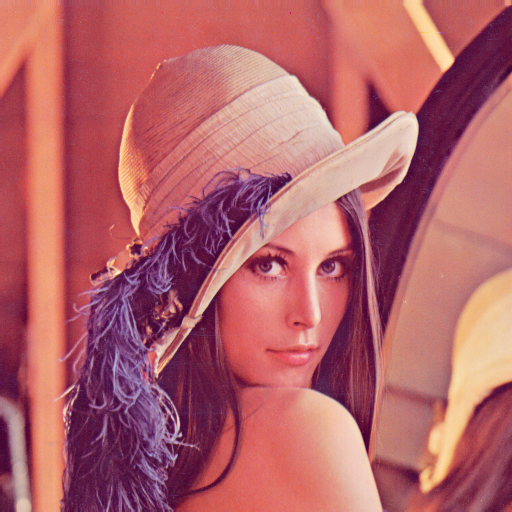

In [123]:
%run download_default_image.ipynb

### Tamaño de bloque

La imagen se divide en bloques de $B \times B$ píxeles. Cada bloque se procesa de forma independiente:

- **Bloques pequeños** (ej. 4×4): Capturan detalles finos pero tienen menos capacidad de compactación de energía
- **Bloques grandes** (ej. 16×16): Mayor capacidad de compactación pero pueden generar artefactos de bloque más visibles

La función `_extract_blocks()` divide la imagen en bloques y los aplana a vectores de $B^2$ elementos. La función `_reconstruct_map()` realiza la operación inversa para reconstruir la imagen.

In [ ]:
%%bash
rm /tmp/encoded*
python ../src/LBT.py encode -q 1 --block_size 4
rm /tmp/decoded.png
python ../src/LBT.py decode -q 1 --block_size 4
python ../src/RDE.py

main Namespace(debug=False, subparser_name='encode', block_size_DCT=4, side_info=None, epochs=1000, lr=0.001, color_transform='YCoCg', perceptual_quantization=False, Lambda=None, disable_subbands=False, quantizer='deadzone', QSS=1, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x76ba0cbc2700>)


(INFO) entropy_image_coding: Written 654318 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=4, side_info=None, color_transform='YCoCg', perceptual_quantization=False, disable_subbands=False, quantizer='deadzone', QSS=1, filter='no_filter', entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x7472b43b6660>)
128 128
Code-stream file: /tmp/encoded.tif length: 654318
Code-stream file: /tmp/encoded.weights.pth length: 4133
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 658463 bytes (20.09) bits/pixel
Decoded image: /tmp/decoded.png 250019 bytes (7.63) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 8.84
J = R + D = 28.94


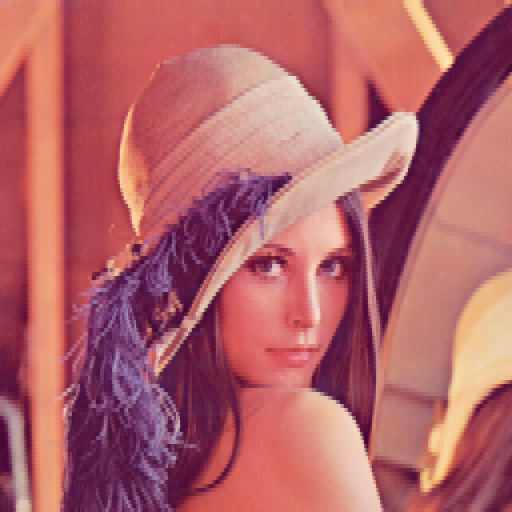

In [148]:
display(Image(filename="/tmp/decoded.png"))

In [126]:
%%bash
rm /tmp/encoded*
python ../src/LBT.py encode -q 1 --block_size 16
rm /tmp/decoded.png
python ../src/LBT.py decode -q 1 --block_size 16
python ../src/RDE.py

main Namespace(debug=False, subparser_name='encode', block_size_DCT=16, side_info=None, epochs=1000, lr=0.001, color_transform='YCoCg', perceptual_quantization=False, Lambda=None, disable_subbands=False, quantizer='deadzone', QSS=1, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x7d6b0f8b6700>)


(INFO) entropy_image_coding: Written 684939 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=16, side_info=None, color_transform='YCoCg', perceptual_quantization=False, disable_subbands=False, quantizer='deadzone', QSS=1, filter='no_filter', entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x7c8c349b6660>)
32 32
Code-stream file: /tmp/encoded.tif length: 684939
Code-stream file: /tmp/encoded.weights.pth length: 526373
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 1211324 bytes (36.97) bits/pixel
Decoded image: /tmp/decoded.png 387273 bytes (11.82) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 5.75
J = R + D = 42.72


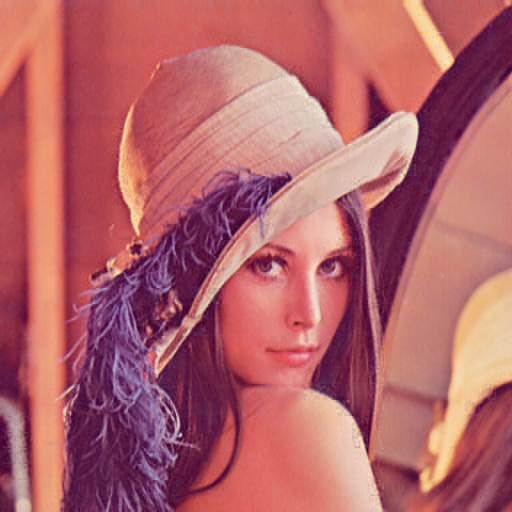

In [127]:
display(Image(filename="/tmp/decoded.png"))

### Entrenamiento del modelo

El entrenamiento del modelo LBT se realiza en `encode_image()` y consiste en:

1. **Preparación de datos**: Los bloques se extraen y centran restando la media global
2. **Optimización**: Se usa el optimizador Adam para minimizar la función de pérdida
3. **Función de pérdida**: 
   - **MSE**: Error cuadrático medio entre los bloques originales y reconstruidos
   - **Coding Gain**: Término que penaliza la varianza de los coeficientes, fomentando la compactación de energía en pocos coeficientes

$$\mathcal{L} = MSE + \lambda \cdot \frac{1}{N}\sum_{i=1}^{N} \log(\sigma_i^2)$$

donde $\sigma_i^2$ es la varianza del coeficiente $i$. Este término ayuda a que la transformada concentre la energía en pocos coeficientes, mejorando la compresión.

In [ ]:
%%bash 
rm /tmp/encoded*
python ../src/LBT.py encode -q 1 --block_size 4 --epochs 10 --lr 1e-2
rm /tmp/decoded.png
python ../src/LBT.py decode -q 1 --block_size 4
python ../src/RDE.py

main Namespace(debug=False, subparser_name='encode', block_size_DCT=4, side_info=None, epochs=100, lr=0.01, color_transform='YCoCg', perceptual_quantization=False, Lambda=None, disable_subbands=False, quantizer='deadzone', QSS=1, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x7123858ba700>)


(INFO) entropy_image_coding: Written 614671 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=4, side_info=None, color_transform='YCoCg', perceptual_quantization=False, disable_subbands=False, quantizer='deadzone', QSS=1, filter='no_filter', entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x764ec8ac2660>)
128 128
Code-stream file: /tmp/encoded.tif length: 614671
Code-stream file: /tmp/encoded.weights.pth length: 4133
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 618816 bytes (18.88) bits/pixel
Decoded image: /tmp/decoded.png 237658 bytes (7.25) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 10.28
J = R + D = 29.17


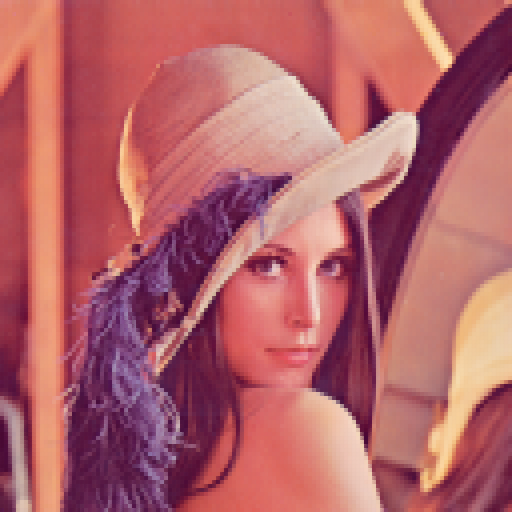

In [157]:
display(Image(filename="/tmp/decoded.png"))

In [130]:
%%bash
rm /tmp/encoded*
python ../src/LBT.py encode -q 1 --block_size 8 --epochs 10 --lr 1e-2 --L 10
rm /tmp/decoded.png
python ../src/LBT.py decode -q 1 --block_size 8
python ../src/RDE.py

main Namespace(debug=False, subparser_name='encode', block_size_DCT=8, side_info=None, epochs=10, lr=0.01, color_transform='YCoCg', perceptual_quantization=False, Lambda=10, disable_subbands=False, quantizer='deadzone', QSS=1, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x7e70055be700>)


(INFO) entropy_image_coding: Written 691833 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=8, side_info=None, color_transform='YCoCg', perceptual_quantization=False, disable_subbands=False, quantizer='deadzone', QSS=1, filter='no_filter', entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x71dbe31b6660>)
64 64
Code-stream file: /tmp/encoded.tif length: 691833
Code-stream file: /tmp/encoded.weights.pth length: 34853
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 726698 bytes (22.18) bits/pixel
Decoded image: /tmp/decoded.png 439165 bytes (13.40) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 22.12
J = R + D = 44.29


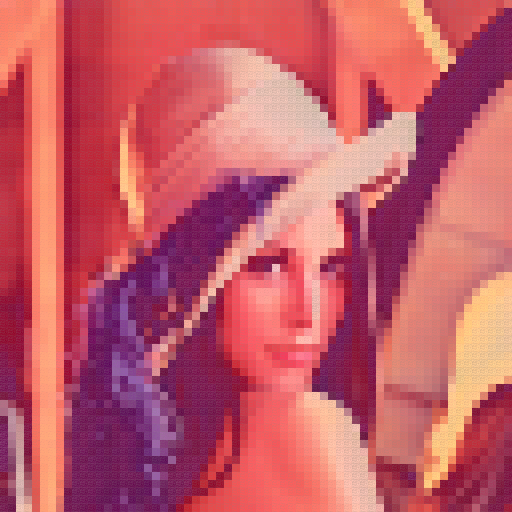

In [131]:
display(Image(filename="/tmp/decoded.png"))

### Quantization

La cuantización es el proceso de reducir la precisión de los coeficientes transformados para lograr compresión. Consiste en dividir cada coeficiente por un paso de cuantización (`-q`) y redondear al entero más cercano.

- **Mayor `-q`**: Más compresión pero mayor pérdida de calidad (más artefactos)
- **Menor `-q`**: Mejor calidad pero menor compresión

**Cuantización perceptual** (`-p`): Utiliza las matrices de cuantización de JPEG, que aplican cuantización más agresiva a las frecuencias altas (menos perceptibles por el ojo humano) y más suave a las frecuencias bajas (más importantes visualmente). Las matrices `Y_QSSs` y `C_QSSs` definen los pasos de cuantización para luminancia y crominancia respectivamente.

In [132]:
%%bash
rm /tmp/encoded*
python ../src/LBT.py encode -q 32 --block_size 16
rm /tmp/decoded.png
python ../src/LBT.py decode -q 32 --block_size 16
python ../src/RDE.py

main Namespace(debug=False, subparser_name='encode', block_size_DCT=16, side_info=None, epochs=1000, lr=0.001, color_transform='YCoCg', perceptual_quantization=False, Lambda=None, disable_subbands=False, quantizer='deadzone', QSS=32, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x76e685bbe700>)


(INFO) entropy_image_coding: Written 111787 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=16, side_info=None, color_transform='YCoCg', perceptual_quantization=False, disable_subbands=False, quantizer='deadzone', QSS=32, filter='no_filter', entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x7c6af75c2660>)
32 32
Code-stream file: /tmp/encoded.tif length: 111787
Code-stream file: /tmp/encoded.weights.pth length: 526373
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 638172 bytes (19.48) bits/pixel
Decoded image: /tmp/decoded.png 492151 bytes (15.02) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 23.60
J = R + D = 43.08


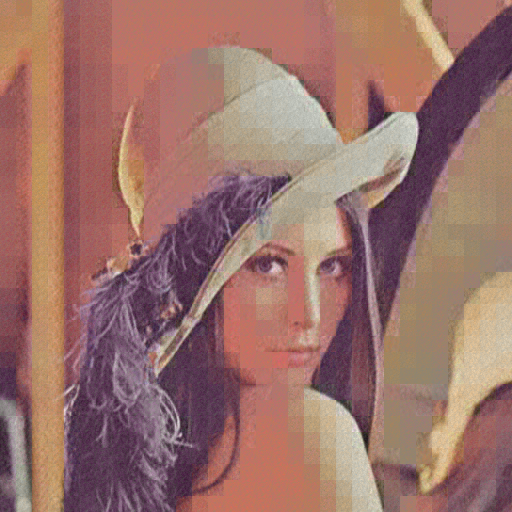

In [133]:
display(Image(filename="/tmp/decoded.png"))

In [134]:
%%bash
rm /tmp/encoded*
python ../src/LBT.py encode -p -q 8 -B 32
rm /tmp/decoded.png
python ../src/LBT.py decode -p -q 8 -B 32
python ../src/RDE.py

main Namespace(debug=False, subparser_name='encode', block_size_DCT=32, side_info=None, epochs=1000, lr=0.001, color_transform='YCoCg', perceptual_quantization=True, Lambda=None, disable_subbands=False, quantizer='deadzone', QSS=8, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x751f9e3ba700>)


(INFO) entropy_image_coding: Written 251643 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=32, side_info=None, color_transform='YCoCg', perceptual_quantization=True, disable_subbands=False, quantizer='deadzone', QSS=8, filter='no_filter', entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x7de1029be660>)
16 16
Code-stream file: /tmp/encoded.tif length: 251643
Code-stream file: /tmp/encoded.weights.pth length: 8390693
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 8642348 bytes (263.74) bits/pixel
Decoded image: /tmp/decoded.png 551655 bytes (16.84) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 17.95
J = R + D = 281.70


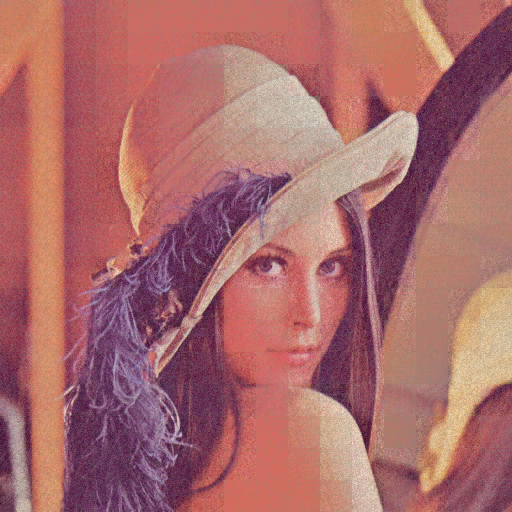

In [135]:
display(Image(filename="/tmp/decoded.png"))

## Using LloydMax

**LloydMax** es un cuantizador no uniforme que optimiza los niveles de cuantización según la distribución estadística de los datos. A diferencia del cuantizador uniforme (deadzone), LloydMax:

- Asigna más niveles de cuantización donde hay mayor densidad de valores
- Minimiza el error cuadrático medio de cuantización
- Requiere especificar el rango de valores esperados con `-m` (mínimo) y `-n` (máximo)

Es especialmente útil cuando la distribución de los coeficientes no es uniforme, lo cual es típico en transformadas como DCT o LBT.

In [137]:
%%bash
rm /tmp/encoded*
python ../src/LBT.py encode -q 16 -a LloydMax -m -2048 -n 2047 
rm /tmp/decoded.png
python ../src/LBT.py decode -q 16 -a LloydMax -m -2048 -n 2047 
python ../src/RDE.py

rm: cannot remove '/tmp/encoded*': No such file or directory


main Namespace(debug=False, subparser_name='encode', block_size_DCT=8, side_info=None, epochs=1000, lr=0.001, color_transform='YCoCg', perceptual_quantization=False, Lambda=None, disable_subbands=False, quantizer='LloydMax', QSS=16, min_val=-2048, max_val=2047, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x7d205a5ba700>)


(INFO) LloydMax: min_val = -2048
(INFO) LloydMax: max_val = 2047
(INFO) LloydMax: QSS = 16
(INFO) LloydMax: QSS = 16
(INFO) LloydMax: histogram = [0 0 0 ... 0 0 0]
(INFO) LloydMax: Written 891 bytes in /tmp/encoded_centroids_0.gz
(INFO) LloydMax: histogram = [0 0 0 ... 0 0 0]
(INFO) LloydMax: Written 662 bytes in /tmp/encoded_centroids_1.gz
(INFO) LloydMax: histogram = [0 0 0 ... 0 0 0]
(INFO) LloydMax: Written 683 bytes in /tmp/encoded_centroids_2.gz
(INFO) entropy_image_coding: Written 196894 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=8, side_info=None, color_transform='YCoCg', perceptual_quantization=False, disable_subbands=False, quantizer='LloydMax', QSS=16, filter='no_filter', min_val=-2048, max_val=2047, entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x7acea89be660>)


(INFO) LloydMax: min_val = -2048
(INFO) LloydMax: max_val = 2047
(INFO) LloydMax: QSS = 16
(INFO) LloydMax: QSS = 16
(INFO) LloydMax: min_val=-2048
(INFO) LloydMax: max_val=2047
(INFO) LloydMax: Read /tmp/encoded_centroids_0.gz
(INFO) LloydMax: Read /tmp/encoded_centroids_1.gz
(INFO) LloydMax: Read /tmp/encoded_centroids_2.gz


64 64
Code-stream file: /tmp/encoded_params.txt length: 14
Code-stream file: /tmp/encoded_centroids_0.gz length: 891
Code-stream file: /tmp/encoded_centroids_1.gz length: 662
Code-stream file: /tmp/encoded_centroids_2.gz length: 683
Code-stream file: /tmp/encoded.tif length: 196894
Code-stream file: /tmp/encoded.weights.pth length: 34853
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded_params.txt', '/tmp/encoded_centroids_0.gz', '/tmp/encoded_centroids_1.gz', '/tmp/encoded_centroids_2.gz', '/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 234009 bytes (7.14) bits/pixel
Decoded image: /tmp/decoded.png 377525 bytes (11.52) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 8.90
J = R + D = 16.05


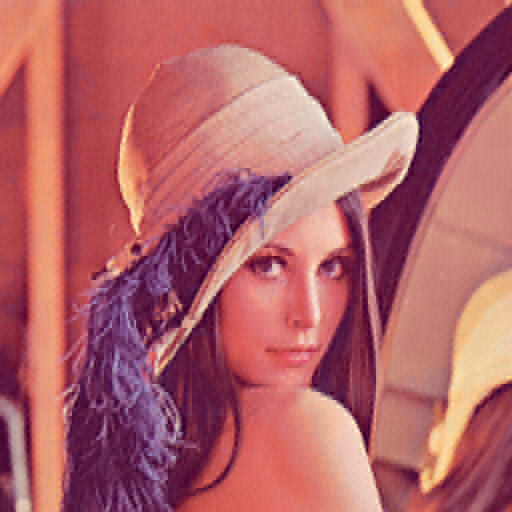

In [138]:
display(Image(filename="/tmp/decoded.png"))

In [139]:
%%bash
rm /tmp/encoded*
python ../src/LBT.py encode -q 1 -a LloydMax -m -2048 -n 2047 
rm /tmp/decoded.png
python ../src/LBT.py decode -q 1 -a LloydMax -m -2048 -n 2047 
python ../src/RDE.py

main Namespace(debug=False, subparser_name='encode', block_size_DCT=8, side_info=None, epochs=1000, lr=0.001, color_transform='YCoCg', perceptual_quantization=False, Lambda=None, disable_subbands=False, quantizer='LloydMax', QSS=1, min_val=-2048, max_val=2047, entropy_image_codec='TIFF', original='/tmp/original.png', encoded='/tmp/encoded', func=<function encode at 0x7aae5feba700>)


(INFO) LloydMax: min_val = -2048
(INFO) LloydMax: max_val = 2047
(INFO) LloydMax: QSS = 1
(INFO) LloydMax: QSS = 1
(INFO) LloydMax: histogram = [0 0 0 ... 0 0 0]
(INFO) LloydMax: Written 5585 bytes in /tmp/encoded_centroids_0.gz
(INFO) LloydMax: histogram = [0 0 0 ... 0 0 0]
(INFO) LloydMax: Written 5585 bytes in /tmp/encoded_centroids_1.gz
(INFO) LloydMax: histogram = [0 0 0 ... 0 0 0]
(INFO) LloydMax: Written 5585 bytes in /tmp/encoded_centroids_2.gz
(INFO) entropy_image_coding: Written 1157 bytes in /tmp/encoded.tif


Denoising filter = no_filter
main Namespace(debug=False, subparser_name='decode', block_size_DCT=8, side_info=None, color_transform='YCoCg', perceptual_quantization=False, disable_subbands=False, quantizer='LloydMax', QSS=1, filter='no_filter', min_val=-2048, max_val=2047, entropy_image_codec='TIFF', encoded='/tmp/encoded', decoded='/tmp/decoded.png', func=<function decode at 0x73c6c22be660>)


(INFO) LloydMax: min_val = -2048
(INFO) LloydMax: max_val = 2047
(INFO) LloydMax: QSS = 1
(INFO) LloydMax: QSS = 1
(INFO) LloydMax: min_val=-2048
(INFO) LloydMax: max_val=2047
(INFO) LloydMax: Read /tmp/encoded_centroids_0.gz
(INFO) LloydMax: Read /tmp/encoded_centroids_1.gz
(INFO) LloydMax: Read /tmp/encoded_centroids_2.gz


64 64
Code-stream file: /tmp/encoded_params.txt length: 13
Code-stream file: /tmp/encoded_centroids_0.gz length: 5585
Code-stream file: /tmp/encoded_centroids_1.gz length: 5585
Code-stream file: /tmp/encoded_centroids_2.gz length: 5585
Code-stream file: /tmp/encoded.tif length: 1157
Code-stream file: /tmp/encoded.weights.pth length: 34853
Code-stream file: /tmp/encoded_shape.bin length: 12
Original image: /tmp/original.png 512673 bytes (15.65) bits/pixel
Code-stream: ['/tmp/encoded_params.txt', '/tmp/encoded_centroids_0.gz', '/tmp/encoded_centroids_1.gz', '/tmp/encoded_centroids_2.gz', '/tmp/encoded.tif', '/tmp/encoded.weights.pth', '/tmp/encoded_shape.bin'] 52790 bytes (1.61) bits/pixel
Decoded image: /tmp/decoded.png 4293 bytes (0.13) bits/pixel
Images shape: (512, 512, 3)
Distortion (RMSE): 127.08
J = R + D = 128.70


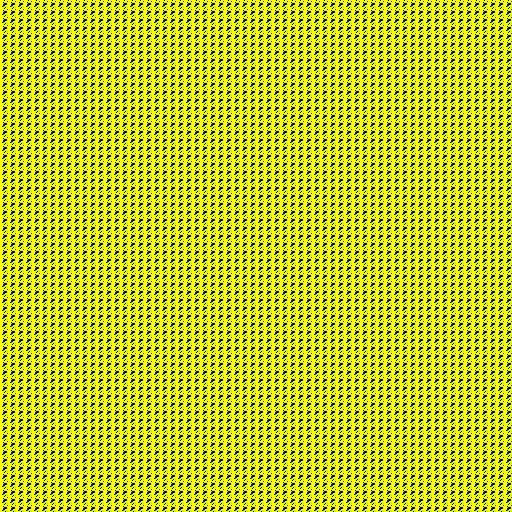

In [140]:
display(Image(filename="/tmp/decoded.png"))